# Cargar documentos

In [18]:
import sys
print(sys.executable)

/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/bin/python


In [19]:
import os
import pandas as pd 
import numpy as np

In [20]:
active_subjects = pd.read_csv(os.path.join("..", "..","data", "active_subjects.csv"))
audiences = pd.read_csv(os.path.join("..", "..","data", 'audiencies.csv'))
institutions = pd.read_csv(os.path.join("..", "..","data", 'institutions.csv'))
passive_subjects = pd.read_csv(os.path.join("..", "..","data", 'passive_subjects.csv'))

In [21]:
df_grande = pd.merge(
    active_subjects,
    audiences,
    on='audiencia_id',
    how='inner'  # solo registros que existen en ambos
)

In [22]:
df = df_grande.copy()
df = df[['sujeto_pasivo_id_x','Nombre completo','materias_tratadas','especificacion']]
df = df.rename(columns={
    'sujeto_pasivo_id_x': 'pasivo_id',
    'Nombre completo': 'activo_id',
    'materias_tratadas': 'temas',
    'especificacion': 'detalle'
})

In [23]:
ruta_parquet = 'lobby_data_para_gpu.parquet'
df_parquet = pd.read_parquet(ruta_parquet)

# 2. Reemplazas la columna (usando .values para asignar por posición estricta)
# Esto asume que df tiene la misma cantidad de filas y el mismo orden que el parquet
df['detalle'] = df_parquet['detalle'].values

In [24]:
df['detalle'][1]

'Socios de JJVV de Caquena solicitan audiencia presencial con Delegado debido a traslado de alumnos de colegio desde Caquena a Chujlluta por falta de profesores. Vecinos buscan solución y acuden al Deelgado para realizar nexo con Seremi de Educación'

In [25]:
df

,pasivo_id,activo_id,temas,detalle
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...
...,...,...,...,...
1153805,391700,JAIME OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153806,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153807,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153808,712954,Margarita Corrotea,"Diseño, implementación y evaluación de polític...","encomendada compañía ESVAL, entregar informaci..."


# Modelo recomendador

In [ ]:
import umap
import hdbscan
import gc
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import numpy as np

print("=== BLOQUE 2: RE-CLUSTERING (MAPA NUEVO) ===")

# 1. PCA (768 -> 50)
print("1. Ejecutando PCA...")
# Normalizamos antes de PCA para que la distancia coseno funcione óptimamente
emb_norm = normalize(emb_detalle) 
pca = PCA(n_components=50, random_state=42)
emb_pca = pca.fit_transform(emb_norm)

# 2. UMAP Híbrido (Para cuidar la RAM)
print("2. Ejecutando UMAP...")
# Entrenamos el mapa solo con una muestra de 200k (suficiente para aprender la topología)
mapper = umap.UMAP(
    n_neighbors=5, 
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42, 
    low_memory=True,
    verbose=True
).fit(emb_pca[:200000]) 

# Proyectamos todo el dataset por partes para no saturar memoria
print("   Proyectando el resto de los datos...")
umap_embeddings_list = []
batch_size = 50000

for i in range(0, len(emb_pca), batch_size):
    batch = emb_pca[i : i + batch_size]
    batch_emb = mapper.transform(batch)
    umap_embeddings_list.append(batch_emb)

umap_embeddings = np.vstack(umap_embeddings_list)
print(f"   Mapa UMAP listo: {umap_embeddings.shape}")

# 3. HDBSCAN (Etiquetado)
print("3. Ejecutando HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,
    min_samples=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
labels = clusterer.fit_predict(umap_embeddings)

# Actualizamos el DataFrame
df['cluster_final'] = labels

# Reporte
n_clusters = len(np.unique(labels)) - 1
ruido = (len(labels[labels == -1]) / len(labels)) * 100
print(f"✅ ¡Nuevos Clusters Listos!")
print(f"   Total Clusters: {n_clusters}")
print(f"   Ruido: {ruido:.2f}%")

=== BLOQUE 2A: REDUCCIÓN DE DIMENSIONALIDAD (PCA + UMAP) ===
1. Ejecutando PCA...
2. Ejecutando UMAP...
   Entrenando mapa con 600000 documentos...
UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=5, n_jobs=1, random_state=42, verbose=True)
Fri Nov 28 23:14:32 2025 Construct fuzzy simplicial set
Fri Nov 28 23:14:32 2025 Finding Nearest Neighbors
Fri Nov 28 23:14:32 2025 Building RP forest with 44 trees


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Nov 28 23:14:44 2025 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	 3  /  19
	 4  /  19
	 5  /  19
	 6  /  19
	Stopping threshold met -- exiting after 6 iterations
Fri Nov 28 23:15:14 2025 Finished Nearest Neighbor Search
Fri Nov 28 23:15:15 2025 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


...

	completed  50  /  100 epochs
	completed  60  /  100 epochs


Epochs completed:  83%| ████████▎  83/100 [00:01]

	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Epochs completed: 100%| ██████████ 100/100 [00:01]

✅ Mapa UMAP listo: (1153810, 5)


In [ ]:
import hdbscan
import numpy as np
import pandas as pd # Aseguramos que pandas esté importado

print("=== RE-TUNING HDBSCAN (MENOS RUIDO) ===")

# AJUSTES NUEVOS
# min_cluster_size: Bajamos de 150 a 100 para aceptar temas medianos
# min_samples: Bajamos de 30 a 10 (ESTO ES LO QUE BAJA EL RUIDO DRASTICAMENTE)
new_min_cluster_size = 100
new_min_samples = 10

print(f"Ejecutando con Size={new_min_cluster_size}, Samples={new_min_samples}...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=new_min_cluster_size,
    min_samples=new_min_samples,
    metric='euclidean',
    cluster_selection_method='eom', 
    prediction_data=True
)

labels = clusterer.fit_predict(umap_embeddings)

# Actualizamos DF
df['cluster_final'] = labels

# Métricas
n_clusters = len(np.unique(labels)) - 1
ruido_pct = (len(labels[labels == -1]) / len(labels)) * 100

print(f"\n📊 RESULTADOS MEJORADOS:")
print(f"   Total Clusters: {n_clusters}")
print(f"   Ruido: {ruido_pct:.2f}%")

if ruido_pct < 40:
    print("   ✅ ¡Excelente! Ruido bajo control.")
else:
    print("   ⚠️ Aún hay bastante ruido. Podríamos probar 'soft clustering' después.")

=== RE-TUNING HDBSCAN (MENOS RUIDO) ===
Ejecutando con Size=100, Samples=10...


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
Python(62292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Python(62293


📊 RESULTADOS MEJORADOS:
   Total Clusters: 1279
   Ruido: 54.42%
   ⚠️ Aún hay bastante ruido. Podríamos probar 'soft clustering' después.


In [ ]:
df.head()

,pasivo_id,activo_id,temas,detalle,cluster_final
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...,1213
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...,1147
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...,-1
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...,-1
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...,1272


In [ ]:
import joblib
import os

print("=== GUARDANDO SISTEMA COMPLETO ===")

# Crear carpeta
os.makedirs("sistema_lobby_final", exist_ok=True)

# 1. Guardar Modelos de Reducción y Clustering
print("Guardando modelos (PCA, UMAP, HDBSCAN)...")
joblib.dump(pca, "sistema_lobby_final/pca_model.joblib")
joblib.dump(mapper, "sistema_lobby_final/umap_model.joblib")
joblib.dump(clusterer, "sistema_lobby_final/hdbscan_model.joblib")

# 2. Guardar DataFrame Enriquecido (Con clusters y limpio)
print("Guardando Base de Datos Maestra...")
df.to_parquet("sistema_lobby_final/df_lobby_clustered.parquet")

# 3. Guardar Embeddings Alineados
print("Guardando Vectores...")
np.save("sistema_lobby_final/embeddings_bert.npy", emb_detalle)

print("✅ ¡TODO GUARDADO! Tu sistema es persistente.")
print("La próxima vez, solo carga estos archivos e instancia la clase LobbyRecommender.")

=== GUARDANDO SISTEMA COMPLETO ===
Guardando modelos (PCA, UMAP, HDBSCAN)...
Guardando Base de Datos Maestra...
Guardando Vectores...
✅ ¡TODO GUARDADO! Tu sistema es persistente.
La próxima vez, solo carga estos archivos e instancia la clase LobbyRecommender.


# Metricas en el modelo

Cargamos los datos medidos anteriormemente

In [ ]:
# Librerias
import joblib
import os
import torch
import numpy as np
import pandas as pd
import hdbscan
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
import sys
from contextlib import contextmanager
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [31]:

class LobbyRecommender:
    def __init__(self, df_data, embeddings_bert, pca, mapper, clusterer):
        """
        Inicializa el sistema y silencia los modelos internos.
        """
        self.df = df_data.reset_index(drop=True)
        self.embs = embeddings_bert
        self.pca = pca
        
        # --- SILENCIADOR AUTOMÁTICO ---
        # Forzamos a UMAP a guardar silencio, sin importar cómo se entrenó
        self.mapper = mapper
        self.mapper.verbose = False 
        
        self.clusterer = clusterer
        
        # 1. Configuración BERT
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"🔄 Iniciando Recommender en: {self.device}")
        
        model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        
        # 2. Entrenar GPS (KNN)
        print("🧠 Entrenando sistema de navegación (KNN)...")
        embs_norm = normalize(self.embs)
        X_pca_train = self.pca.transform(embs_norm)
        y_labels = self.df['cluster_final'].values 
        
        self.router_knn = KNeighborsClassifier(n_neighbors=15)
        self.router_knn.fit(X_pca_train, y_labels)
        
        print(f"✅ Sistema listo. Total temas disponibles: {len(np.unique(y_labels))}")

    def get_single_embedding(self, text):
        """Genera embedding usando Mean Pooling corregido (sin padding)."""
        inputs = self.tokenizer([str(text)], padding=True, truncation=True,
                                return_tensors='pt', max_length=128).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            token_embeddings = outputs.last_hidden_state
            attention_mask = inputs['attention_mask']
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            emb = sum_embeddings / sum_mask
            
        return emb.cpu().numpy()

    def recomendar(self, nuevo_texto, top_k=5):
        # 1. Vectorizar
        vec_raw = self.get_single_embedding(nuevo_texto)
        vec_norm = normalize(vec_raw)
        
        # 2. Ubicar (UMAP ahora será silencioso)
        vec_pca = self.pca.transform(vec_norm)
        vec_umap = self.mapper.transform(vec_pca)
        
        # 3. Asignar Cluster
        try:
            cluster_id, _ = hdbscan.approximate_predict(self.clusterer, vec_umap)
            cluster_asignado = cluster_id[0]
        except:
            cluster_asignado = -1
            
        metodo = "HDBSCAN"
        if cluster_asignado == -1:
            cluster_asignado = self.router_knn.predict(vec_pca)[0]
            metodo = "KNN (Rescate)"
            
        # 4. Buscar
        candidatos_idx = self.df.index[self.df['cluster_final'] == cluster_asignado].tolist()
        if not candidatos_idx: 
            candidatos_idx = self.df.index.tolist()
            
        embs_candidatos = self.embs[candidatos_idx]
        similitudes = cosine_similarity(vec_raw, embs_candidatos)[0]
        
        top_indices = similitudes.argsort()[::-1][:top_k]
        
        resultados = []
        for loc_idx in top_indices:
            real_idx = candidatos_idx[loc_idx]
            row = self.df.iloc[real_idx]
            resultados.append({
                'pasivo_id': row['pasivo_id'],
                'similitud': float(similitudes[loc_idx]),
                'detalle': str(row['detalle'])[:200] + "...",
                'cluster': int(cluster_asignado),
                'metodo': metodo
            })
            
        return pd.DataFrame(resultados)

In [33]:


# Ruta donde guardaste los archivos
CARPETA_MODELOS = "sistema_lobby_final"

print("=== CARGANDO SISTEMA ===")

if not os.path.exists(CARPETA_MODELOS):
    print(f"❌ ERROR: No encuentro la carpeta '{CARPETA_MODELOS}'.")
    print("   Asegúrate de estar en el directorio correcto o ajusta la ruta.")
else:
    try:
        # 1. Cargar Modelos
        print("📂 Cargando modelos (PCA, UMAP, HDBSCAN)...")
        pca_loaded = joblib.load(f"{CARPETA_MODELOS}/pca_model.joblib")
        mapper_loaded = joblib.load(f"{CARPETA_MODELOS}/umap_model.joblib")
        clusterer_loaded = joblib.load(f"{CARPETA_MODELOS}/hdbscan_model.joblib")

        # 2. Cargar Datos
        print("📂 Cargando Base de Datos (Parquet)...")
        df_loaded = pd.read_parquet(f"{CARPETA_MODELOS}/df_lobby_clustered.parquet")

        # 3. Cargar Vectores
        print("📂 Cargando Embeddings (NPY)...")
        embs_loaded = np.load(f"{CARPETA_MODELOS}/embeddings_bert.npy")

        print("✅ ¡Archivos cargados correctamente!")
        
        # 4. Inicializar Recomendador
        print("\n🚀 Levantando LobbyRecommender...")
        recsys = LobbyRecommender(
            df_data=df_loaded,
            embeddings_bert=embs_loaded,
            pca=pca_loaded,
            mapper=mapper_loaded,
            clusterer=clusterer_loaded
        )
        
        print("\n✨ ¡SISTEMA LISTO PARA USAR!")

    except Exception as e:
        print(f"❌ Ocurrió un error al cargar: {e}")

=== CARGANDO SISTEMA ===
📂 Cargando modelos (PCA, UMAP, HDBSCAN)...
Sat Nov 29 14:14:24 2025 Building and compiling search function
📂 Cargando Base de Datos (Parquet)...
📂 Cargando Embeddings (NPY)...
✅ ¡Archivos cargados correctamente!

🚀 Levantando LobbyRecommender...
🔄 Iniciando Recommender en: cpu
🧠 Entrenando sistema de navegación (KNN)...
✅ Sistema listo. Total temas disponibles: 1779

✨ ¡SISTEMA LISTO PARA USAR!


In [34]:
# 1. Calcular cuántas veces aparece cada pasivo_id en la base de datos
print("Calculando carga de trabajo histórica (Ocupación)...")

# value_counts() nos da la frecuencia (número de reuniones)
mapa_ocupacion = df['pasivo_id'].value_counts().to_dict()

# Ejemplo de verificacion
top_1 = list(mapa_ocupacion.keys())[0]
print(f"✅ Cálculo listo. El sujeto más ocupado (ID {top_1}) tiene {mapa_ocupacion[top_1]} reuniones.")

def get_ocupacion(p_id):
    return mapa_ocupacion.get(p_id, 0)

Calculando carga de trabajo histórica (Ocupación)...
✅ Cálculo listo. El sujeto más ocupado (ID 10832) tiene 12458 reuniones.


In [ ]:

def visualizar_perfil_profesional(df_resultados, df_original, mapa_ocupacion, recsys, texto_query, verbose=True):
    """
    Versión 4.0:
    - Retorna una lista con los 'pasivo_id' recomendados.
    - verbose=False: Silencia los prints (ideal para loops de evaluación).
    - verbose=True: Muestra el reporte completo (sin Temática, solo Cluster ID).
    - Optimización: No calcula antecedentes si verbose=False (ahorra tiempo).
    """
    
    predicted_ids = []
    
    # Solo calculamos el vector de la query si vamos a imprimir detalles visuales
    if verbose:
        vec_query = recsys.get_single_embedding(texto_query).reshape(1, -1)
        print(f"\nINFORME DE RECOMENDACIÓN DE SUJETOS PASIVOS")
        print("=" * 80)
        print(f"CONSULTA: '{texto_query}'")
        print("=" * 80)
    
    # Iteramos sobre los candidatos
    for i, row in df_resultados.iterrows():
        p_id = row['pasivo_id']
        
        # 1. GUARDAR ID (Para evaluación)
        predicted_ids.append(p_id)
        
        # Si NO queremos ver detalles, saltamos al siguiente
        if not verbose:
            continue

        # --- A PARTIR DE AQUÍ SOLO SE EJECUTA SI VERBOSE=TRUE ---
        similitud_global = row['similitud']
        cluster_id = row['cluster']
        total_reuniones = mapa_ocupacion.get(p_id, 0)
        
        try:
            nombre_sujeto = df_original[df_original['pasivo_id'] == p_id].iloc[0]['activo_id']
        except:
            nombre_sujeto = "NOMBRE NO REGISTRADO"

        # --- B. BUSCAR ANTECEDENTES (Solo para visualización) ---
        indices_sujeto = df_original.index[df_original['pasivo_id'] == p_id].tolist()
        vectores_sujeto = recsys.embs[indices_sujeto]
        sims_local = cosine_similarity(vec_query, vectores_sujeto)[0]
        sorted_indices = sims_local.argsort()[::-1]
        
        top_cases_unicos = []
        textos_vistos = set()
        
        for idx_local in sorted_indices:
            idx_real = indices_sujeto[idx_local]
            txt_caso = str(df_original.iloc[idx_real]['detalle']).strip()
            score_caso = sims_local[idx_local]
            
            if txt_caso in textos_vistos: continue
            textos_vistos.add(txt_caso)
            top_cases_unicos.append((txt_caso, score_caso))
            if len(top_cases_unicos) >= 3: break
        
        # --- C. IMPRESIÓN (Sin Temática) ---
        print(f"\nCANDIDATO #{i+1}")
        print("-" * 80)
        print(f"NOMBRE      : {nombre_sujeto}")
        print(f"ID INTERNO  : {p_id}")
        print(f"AFINIDAD    : {similitud_global:.4f}")
        print(f"HISTORIAL   : {total_reuniones} reuniones")
        print(f"CLUSTER ID  : {cluster_id}") # Solo el número
        print("-" * 80)
        print("TOP 3 ANTECEDENTES ÚNICOS:")
        
        for k, (txt, score) in enumerate(top_cases_unicos):
            txt_limpio = txt[:250] + "..." if len(txt) > 250 else txt
            print(f"  {k+1}. [Similitud: {score:.4f}]")
            print(f"     \"{txt_limpio}\"")
            print()
            
        print("\n")
        
    # Retornamos la lista de IDs para que puedas calcular métricas
    return predicted_ids

In [36]:
texto = "reparacion vivienda."
df_rec = recsys.recomendar(texto, top_k=5)

# verbose=True por defecto
ids_recomendados = visualizar_perfil_profesional(df_rec, df, mapa_ocupacion, recsys, texto, verbose=True)

Python(91991) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Epochs completed: 100%| ██████████ 100/100 [00:00]
Python(91992) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



INFORME DE RECOMENDACIÓN DE SUJETOS PASIVOS
CONSULTA: 'reparacion vivienda.'

CANDIDATO #1
--------------------------------------------------------------------------------
NOMBRE      : Nadia Silva
ID INTERNO  : 312933
AFINIDAD    : 0.8651
HISTORIAL   : 32 reuniones
CLUSTER ID  : 2507
--------------------------------------------------------------------------------
TOP 3 ANTECEDENTES ÚNICOS:
  1. [Similitud: 0.8651]
     "reconstrucción de vivienda"

  2. [Similitud: 0.3024]
     "Solicitud a vecina de la representada para regularizar la forma en la cual está construyendo el segundo piso de su vivienda, ya que con ello causó daños estructurales y se niega a repararlos y conceder permiso para hacerlo por cuenta de la representa..."

  3. [Similitud: 0.2677]
     "Para revisar y consultar sobre el estado de revisión de las solicitudes de modificación de deslindes y modificación de permiso de edificación ingresos Nº2023/00163 del 13.06.2023 y Nº2023/00162 del 13.06.2023 respectivamente. A

In [ ]:
# Ejemplo de evaluación manual rápida
texto_prueba = "Solicitud de reunión para presentar proyecto habitacional de viviendas sociales."
target_id_real = 87290 # Supongamos que este es el ID correcto que esperas

# Obtenemos recomendaciones
df_rec = recsys.recomendar(texto_prueba, top_k=10)

# Obtenemos SOLO los IDs (sin imprimir nada en pantalla)
lista_ids_predichos = visualizar_perfil_profesional(df_rec, df, mapa_ocupacion, recsys, texto_prueba, verbose=False)

print(f"IDs Predichos: {lista_ids_predichos}")

# Evaluamos
if target_id_real in lista_ids_predichos:
    print("✅ ¡ÉXITO! El ID correcto fue encontrado.")
else:
    print("❌ Fallo. El ID correcto no está en la lista.")

Epochs completed: 100%| ██████████ 100/100 [00:00]

IDs Predichos: [80325, 80325, 80325, 80325, 80325, 4257, 4257, 4257, 4257, 4257]
❌ Fallo. El ID correcto no está en la lista.


In [40]:

# 1. Definir el Silenciador TOTAL (Stdout + Stderr)
@contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

# 2. Función de Evaluación Actualizada
def evaluar_hit_rates(recsys, n_muestras=100):
    print(f"=== EVALUACIÓN DE HIT RATE (Muestra: {n_muestras}) ===")
    
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    hits_5 = 0
    hits_10 = 0
    hits_20 = 0
    
    # Barra de progreso limpia
    # (Esta SÍ se verá porque está fuera del silenciador)
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras, desc="Evaluando"):
        texto_query = row['detalle']
        target_id = row['pasivo_id']
        
        try:
            # --- ZONA DE SILENCIO ---
            # Aquí adentro nada puede imprimir, ni UMAP ni nadie.
            with suppress_all_output():
                df_res = recsys.recomendar(texto_query, top_k=20)
            # ------------------------
            
            ids_recomendados = df_res['pasivo_id'].tolist()
            
            if target_id in ids_recomendados[:5]: hits_5 += 1
            if target_id in ids_recomendados[:10]: hits_10 += 1
            if target_id in ids_recomendados[:20]: hits_20 += 1
                
        except Exception as e:
            # Si falla, imprimimos fuera del bloque silencioso
            print(f"Error: {e}")
            continue

    hr_5 = (hits_5 / n_muestras) * 100
    hr_10 = (hits_10 / n_muestras) * 100
    hr_20 = (hits_20 / n_muestras) * 100
    
    print("\n📊 RESULTADOS DE RENDIMIENTO:")
    print(f"   🎯 Hit Rate @ 5 : {hr_5:.2f}%")
    print(f"   🎯 Hit Rate @ 10: {hr_10:.2f}%")
    print(f"   🎯 Hit Rate @ 20: {hr_20:.2f}%")
    
    return {"HR@5": hr_5, "HR@10": hr_10, "HR@20": hr_20}

In [41]:

def evaluar_confusion_clusters(recsys, n_muestras=500, top_n_clusters=15):
    """
    Genera la matriz de confusión para los clusters.
    Filtra solo los 'top_n_clusters' más frecuentes para que el gráfico sea legible.
    """
    print(f"=== MATRIZ DE CONFUSIÓN DE CLUSTERS (Muestra: {n_muestras}) ===")
    
    # 1. Muestra aleatoria
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    
    y_true = []
    y_pred = []
    
    print("Prediciendo clusters...")
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras):
        texto = row['detalle']
        cluster_real = row['cluster_final']
        
        # Obtenemos la predicción del sistema
        # Pedimos 1 recomendación solo para ver qué cluster asigna el recomendador internamente
        try:
            # recsys.recomendar devuelve un DF, tomamos la columna 'cluster' de la primera fila
            # OJO: Esto asume que tu método recomendar retorna la columna 'cluster'
            res = recsys.recomendar(texto, top_k=1)
            cluster_predicho = res.iloc[0]['cluster']
            
            y_true.append(cluster_real)
            y_pred.append(cluster_predicho)
        except:
            continue
            
    # 2. Filtrar para el Gráfico (Top N Clusters más populares en la muestra)
    # Convertimos a Series para contar rápido
    s_true = pd.Series(y_true)
    top_clusters = s_true.value_counts().head(top_n_clusters).index.tolist()
    
    # Filtramos las listas para quedarnos solo con datos de esos clusters top
    # Esto es vital porque graficar 1200 clusters colapsaría tu pantalla
    indices_filtrados = [i for i, x in enumerate(y_true) if x in top_clusters and y_pred[i] in top_clusters]
    
    y_true_f = [y_true[i] for i in indices_filtrados]
    y_pred_f = [y_pred[i] for i in indices_filtrados]
    
    # 3. Precisión Global (De todos, no solo los filtrados)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Precisión Global de Asignación de Cluster: {acc:.2%}")
    print(f"   (Qué tan a menudo el sistema asigna el mismo cluster original)")

    # 4. Graficar Matriz
    if len(y_true_f) > 0:
        cm = confusion_matrix(y_true_f, y_pred_f, labels=top_clusters)
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=top_clusters, yticklabels=top_clusters)
        plt.xlabel('Cluster Predicho')
        plt.ylabel('Cluster Real')
        plt.title(f'Matriz de Confusión (Top {top_n_clusters} Clusters más frecuentes)')
        plt.show()
    else:
        print("⚠️ No hay suficientes datos en los top clusters para graficar.")

In [42]:
# 1. APAGAR EL RUIDO DE UMAP (Crucial)
recsys.mapper.verbose = False

# 2. Ejecutar Evaluación
# (Asegúrate de tener la función evaluar_hit_rates definida)
metricas = evaluar_hit_rates(recsys, n_muestras=1000)

=== EVALUACIÓN DE HIT RATE (Muestra: 1000) ===


Evaluando: 100%|██████████| 1000/1000 [00:33<00:00, 29.42it/s]


📊 RESULTADOS DE RENDIMIENTO:
   🎯 Hit Rate @ 5 : 78.10%
   🎯 Hit Rate @ 10: 79.00%
   🎯 Hit Rate @ 20: 79.80%


In [ ]:

def evaluar_mrr(recsys, n_muestras=100, top_k=20):
    print(f"=== EVALUACIÓN DE MRR (Muestra: {n_muestras}) ===")
    
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    reciprocal_ranks = []
    
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras, desc="Calculando MRR"):
        texto_query = row['detalle']
        target_id = row['pasivo_id']
        
        try:
            # Silenciamos UMAP
            with suppress_all_output():
                df_res = recsys.recomendar(texto_query, top_k=top_k)
            
            ids_recomendados = df_res['pasivo_id'].tolist()
            
            if target_id in ids_recomendados:
                # Obtenemos el índice (0-based) y sumamos 1 para el ranking (1-based)
                rank = ids_recomendados.index(target_id) + 1
                reciprocal_ranks.append(1 / rank)
            else:
                # Si no está en el top K, el puntaje es 0
                reciprocal_ranks.append(0)
                
        except Exception as e:
            continue

    mrr_score = np.mean(reciprocal_ranks)
    
    print(f"\n📊 RESULTADO MRR@{top_k}:")
    print(f"   🏆 MRR: {mrr_score:.4f}")
    
    # Interpretación rápida
    pos_promedio = 1 / mrr_score if mrr_score > 0 else 0
    print(f"   (Equivale a encontrar la respuesta correcta, en promedio, en la posición: {pos_promedio:.1f})")
    
    return mrr_score

# --- EJECUTAR EVALUACIÓN ---
mrr = evaluar_mrr(recsys, n_muestras=1000, top_k=20)

=== EVALUACIÓN DE MRR (Muestra: 1000) ===


Calculando MRR: 100%|██████████| 1000/1000 [00:31<00:00, 31.59it/s]


📊 RESULTADO MRR@20:
   🏆 MRR: 0.7669
   (Equivale a encontrar la respuesta correcta, en promedio, en la posición: 1.3)


In [43]:

def evaluar_estabilidad_por_muestra(recsys, sample_sizes=[100, 500, 1000, 1500 ,3000 ,5000 ,10000], n_iteraciones=5):
    """
    Evalúa cómo se comportan las métricas al variar el tamaño de la muestra de prueba.
    """
    resultados = []
    
    print(f"=== ANÁLISIS DE ESTABILIDAD ({n_iteraciones} iteraciones por tamaño) ===")
    
    # Bucle por Tamaño de Muestra (Eje X)
    for n in sample_sizes:
        print(f"\n📏 Evaluando tamaño de muestra: {n}...")
        
        # Bucle de Iteraciones (Semillas distintas para barras de error)
        for i in range(n_iteraciones):
            seed = 42 + i + n # Semilla variable
            
            # Tomamos muestra
            try:
                muestra = recsys.df.sample(n=n, random_state=seed)
            except ValueError:
                print(f"⚠️ No hay suficientes datos para muestra de {n}. Saltando.")
                continue
            
            hits_5 = 0
            hits_10 = 0
            hits_20 = 0
            mrr_sum = 0
            
            # Evaluación
            for _, row in tqdm(muestra.iterrows(), total=n, leave=False, desc=f"Iter {i+1}"):
                texto = row['detalle']
                target = row['pasivo_id']
                
                try:
                    with suppress_all_output(): # Silencio total
                        # Pedimos hasta 20 para cubrir todas las métricas
                        res = recsys.recomendar(texto, top_k=20)
                    
                    ids_rec = res['pasivo_id'].tolist()
                    
                    # Hit Rate
                    if target in ids_rec[:5]: hits_5 += 1
                    if target in ids_rec[:10]: hits_10 += 1
                    if target in ids_rec[:20]: hits_20 += 1
                    
                    # MRR @ 20
                    if target in ids_rec:
                        rank = ids_rec.index(target) + 1
                        mrr_sum += (1 / rank)
                        
                except:
                    continue
            
            # Guardar Métricas de esta vuelta
            resultados.append({
                'Tamaño Muestra': n,
                'Iteracion': i,
                'Métrica': 'Hit Rate @ 5',
                'Valor (%)': (hits_5 / n) * 100
            })
            resultados.append({
                'Tamaño Muestra': n,
                'Iteracion': i,
                'Métrica': 'Hit Rate @ 10',
                'Valor (%)': (hits_10 / n) * 100
            })
            resultados.append({
                'Tamaño Muestra': n,
                'Iteracion': i,
                'Métrica': 'Hit Rate @ 20',
                'Valor (%)': (hits_20 / n) * 100
            })
            # Guardamos MRR aparte (o en el mismo DF con otro nombre de métrica)
            resultados.append({
                'Tamaño Muestra': n,
                'Iteracion': i,
                'Métrica': 'MRR @ 20',
                'Valor (%)': (mrr_sum / n) # MRR suele ir de 0 a 1, aquí lo dejamos raw o x100
            })
            
    return pd.DataFrame(resultados)

In [47]:
# 1. Configurar Tamaños
# Nota: Si pones 10,000 puede tardar mucho. Ajusta según tu paciencia.
tamanos = [100 , 500, 1000, 2000, 10000] 

# 2. Ejecutar (Esto tardará unos minutos)
df_estabilidad = evaluar_estabilidad_por_muestra(recsys, sample_sizes=tamanos, n_iteraciones=1)

=== ANÁLISIS DE ESTABILIDAD (1 iteraciones por tamaño) ===

📏 Evaluando tamaño de muestra: 100...



📏 Evaluando tamaño de muestra: 500...



📏 Evaluando tamaño de muestra: 1000...



📏 Evaluando tamaño de muestra: 2000...



📏 Evaluando tamaño de muestra: 10000...


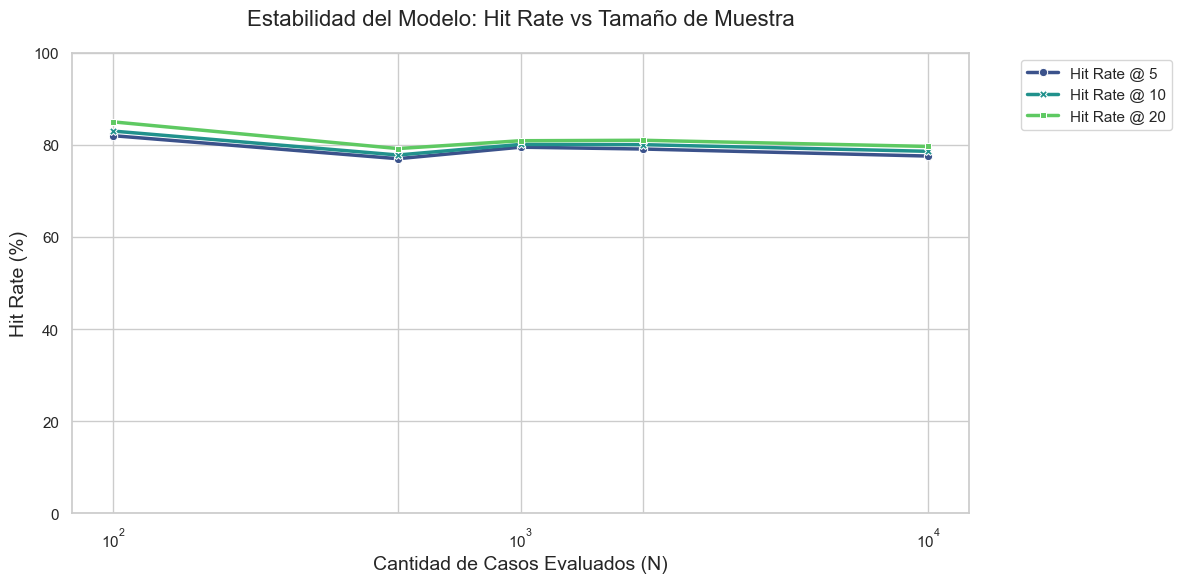

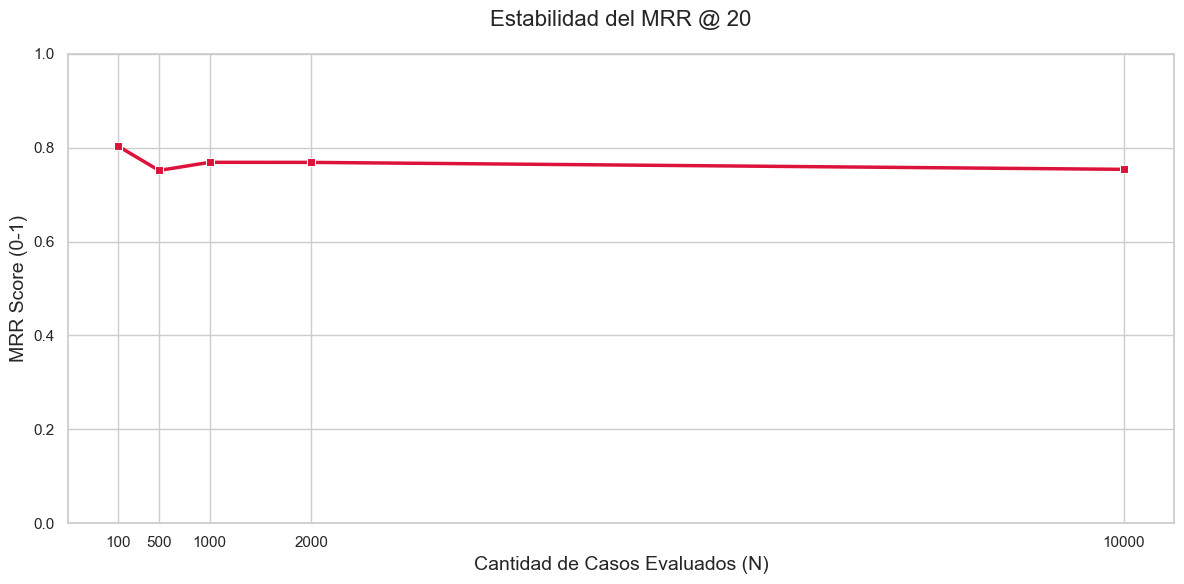

In [48]:
# 3. GRAFICAR HIT RATES
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Filtramos solo las filas de Hit Rate
df_hits = df_estabilidad[df_estabilidad['Métrica'].str.contains("Hit Rate")]

ax = sns.lineplot(
    data=df_hits,
    x="Tamaño Muestra",
    y="Valor (%)",
    hue="Métrica",        # Colores distintos para @5, @10, @20
    style="Métrica",      # Estilos de línea distintos
    markers=True, dashes=False, linewidth=2.5,
    palette="viridis"     # Paleta de colores bonita
)

plt.title("Estabilidad del Modelo: Hit Rate vs Tamaño de Muestra", fontsize=16, pad=20)
plt.ylabel("Hit Rate (%)", fontsize=14)
plt.xlabel("Cantidad de Casos Evaluados (N)", fontsize=14)
plt.ylim(0, 100)
plt.xscale("log")
plt.xticks(tamanos) # Forzar que salgan los números del eje X
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda afuera para no tapar

plt.tight_layout()
plt.show()

# 4. GRAFICAR MRR (Separado porque la escala es distinta o conceptualmente diferente)
plt.figure(figsize=(12, 6))
df_mrr = df_estabilidad[df_estabilidad['Métrica'] == "MRR @ 20"]

ax2 = sns.lineplot(
    data=df_mrr,
    x="Tamaño Muestra",
    y="Valor (%)",
    color="crimson",
    marker="s", linewidth=2.5
)

plt.title("Estabilidad del MRR @ 20", fontsize=16, pad=20)
plt.ylabel("MRR Score (0-1)", fontsize=14)
plt.xlabel("Cantidad de Casos Evaluados (N)", fontsize=14)
plt.xticks(tamanos)
plt.ylim(0, 1) # MRR es de 0 a 1

plt.tight_layout()
plt.show()

# Prueba de robustes/data Leak

In [145]:
import random

def mutilar_texto(texto):
    """Simula una búsqueda humana imperfecta: corta el texto y quita palabras."""
    palabras = texto.split()
    if len(palabras) < 3: return texto
    
    # Simulación 1: El usuario solo escribe la primera mitad de la idea
    mitad = len(palabras) // 2
    texto_mutilado = " ".join(palabras[:mitad])
    
    return texto_mutilado

# --- EVALUACIÓN ROBUSTA ---
def evaluar_hit_rate_robusto(recsys, n_muestras=1000):
    print(f"=== EVALUACIÓN ROBUSTA (TEXTO MUTILADO) ===")
    print("Nota: Aquí el vector de búsqueda ES DISTINTO al guardado.")
    
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    hits_10 = 0
    
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras, desc="Evaluando"):
        texto_original = row['detalle']
        target_id = row['pasivo_id']
        
        # MUTILAMOS EL TEXTO (Simulamos usuario perezoso)
        texto_sucio = mutilar_texto(texto_original)
        
        try:
            with suppress_all_output():
                df_res = recsys.recomendar(texto_sucio, top_k=10)
            
            ids_rec = df_res['pasivo_id'].tolist()
            if target_id in ids_rec:
                hits_10 += 1
        except:
            continue
            
    hr = (hits_10 / n_muestras) * 100
    print(f"\n📊 Hit Rate@10 (ROBUSTO): {hr:.2f}%")
    print(f"   (Si esto es > 40%, tu modelo es inteligente y no solo memoria)")

# Ejecutar
evaluar_hit_rate_robusto(recsys, n_muestras=100)

=== EVALUACIÓN ROBUSTA (TEXTO MUTILADO) ===
Nota: Aquí el vector de búsqueda ES DISTINTO al guardado.


Evaluando: 100%|██████████| 100/100 [00:02<00:00, 39.95it/s]


📊 Hit Rate@10 (ROBUSTO): 34.00%
   (Si esto es > 40%, tu modelo es inteligente y no solo memoria)
